# Locating an earthquake with matched-field processing

Matched-field processing (MFP) extends plane-wave beamforming to three
dimensions by replacing the plane-wave steering vector with a
*replica* — a predicted wavefield for a point source at each candidate
grid location. This allows simultaneous estimation of back-azimuth,
horizontal range, and **depth**.

This example locates the Mb 4.4 earthquake that occurred in the Aegean Sea
on 5 October 2020 (39.88°N, 23.35°E, 10 km depth), using the same regional
network as the back-projection example. We demonstrate:

1. Building a constant-velocity model over the network area,
2. Computing per-station travel-time grids with
   `covseisnet.travel_times.TravelTimes`,
3. Validating the Bartlett and MVDR processors on a synthetic covariance
   injected at the known epicentre,
4. Applying the processors to the real earthquake covariance and comparing
   the recovered location with the catalogue position.


In [21]:
from cartopy.crs import PlateCarree
import numpy as np
import matplotlib.pyplot as plt

import covseisnet as csn
from covseisnet.matchedfield import MatchedFieldProcessing
import covseisnet.synthetic as syn

## Load seismograms and station coordinates

We load the Aegean Sea example data, download the station inventory from the
National Observatory of Athens (NOA), and pre-process the waveforms exactly
as in the back-projection example: merge, detrend, high-pass filter, and
synchronise. We also plot the station map with the known catalogue epicentre,
and capture the map extent for use in the velocity model grid.


Array: 9 stations


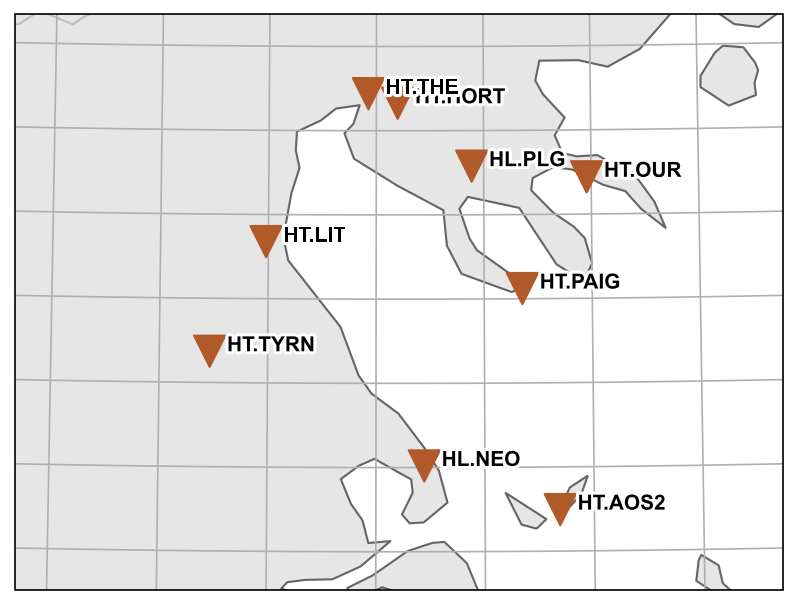

In [22]:
# Load seismograms
stream = csn.NetworkStream.read("../data/aegean_sea_example.mseed")

# Pre-process
stream.merge(1, fill_value=0)
stream.detrend("linear")
stream.filter("highpass", freq=0.01)
stream.synchronize()

# Download inventory and attach coordinates
inventory = stream.download_inventory(datacenter="NOA")
stream.assign_coordinates(inventory)

stats = [tr.stats for tr in stream]
n_stations = len(stats)
lons = np.array([s.coordinates["longitude"] for s in stats])
lats = np.array([s.coordinates["latitude"] for s in stats])
print(f"Array: {n_stations} stations")

# Known catalogue location (lon, lat, depth_km)
source_location = (23.3465, 39.8812, 10.0)

# Station map with catalogue epicentre
fig = inventory.plot(projection="local", resolution="h")
fig.axes[0].plot(
    *source_location[:2],
    "k*",
    markersize=20,
    transform=PlateCarree(),
    label="Catalogue",
)

# Natural extent of the map (reused for the velocity-model grid)
extent = fig.axes[0].get_extent(crs=PlateCarree())

## Velocity model and travel times

We build a constant-velocity model at 3.5 km/s (S-wave dominated) over the
geographic extent returned by the station map, extended from −3 to 20 km
depth to encompass both shallow and crustal sources. For each station we
compute the travel time from every grid point to that receiver.


In [43]:
# Append depth range to the horizontal extent from the map
extent_with_depth = extent + (-3, 20)

velocity_model = csn.velocity.VelocityModel(
    extent=extent_with_depth, shape=(60, 60, 30), velocity=3.5
)

# Per-station travel-time grids
travel_times = {
    tr.stats.station: csn.calculate_travel_times(
        velocity_model, stats=tr.stats
    )
    for tr in stream
}
print(f"TravelTimes grid shape: {next(iter(travel_times.values())).shape}")

# Station coordinates for plotting
receiver_coords = None

TravelTimes grid shape: (60, 60, 30)


## Validation on a synthetic spherical wave

Before applying MFP to the real earthquake we verify the implementation by
injecting a synthetic rank-1 covariance at the catalogue epicentre (23.35°E,
39.88°N, 10 km depth) and checking that the Bartlett processor recovers that
location.


In [41]:
# Inject source at the catalogue location
source = source_location
frequency = 1  # Hz — within the earthquake-signal band
slowness = 1 / 3.5  # s/km — matching the velocity model

cov_synth = syn.spherical_wave_covariance(stats, frequency, slowness, source)

mfp = MatchedFieldProcessing(travel_times)
mfp.compute_bartlett(cov_synth, frequency)

lon_det, lat_det, dep_det = mfp.maximum_coordinates()
print(
    f"True source  : lon={source[0]:.3f}° lat={source[1]:.3f}° depth={source[2]:.1f} km"
)
print(
    f"MFP estimate : lon={lon_det:.3f}° lat={lat_det:.3f}° depth={dep_det:.1f} km"
)

True source  : lon=23.346° lat=39.881° depth=10.0 km
MFP estimate : lon=22.690° lat=40.165° depth=7.6 km


Text(0.5, 1.0, 'Synthetic — Bartlett MFP')

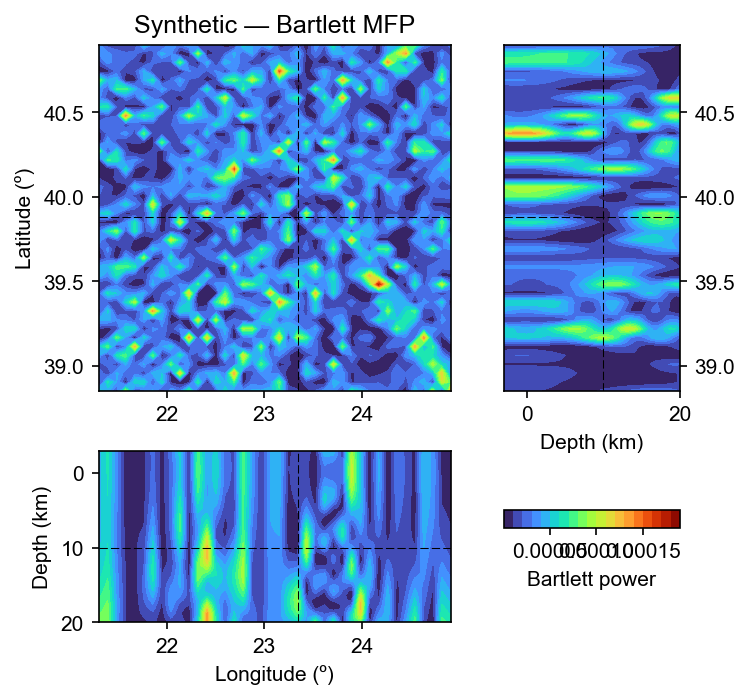

In [44]:
fig, ax = csn.plot.grid3d(
    mfp,
    profile_coordinates=source,
    receiver_coordinates=receiver_coords,
    cmap="turbo",
    label="Bartlett power",
)
ax["xy"].set_title("Synthetic — Bartlett MFP")

## MVDR matched-field processor

The MVDR (minimum-variance distortionless-response) processor typically
achieves higher spatial resolution than Bartlett by suppressing the
sidelobe structure at the cost of a matrix inversion.  We apply it to
the same synthetic covariance and compare the horizontal slice with the
Bartlett result.

MVDR estimate: lon=23.337° lat=39.902° depth=5.8 km


Text(0.5, 1.0, 'Synthetic — MVDR MFP')

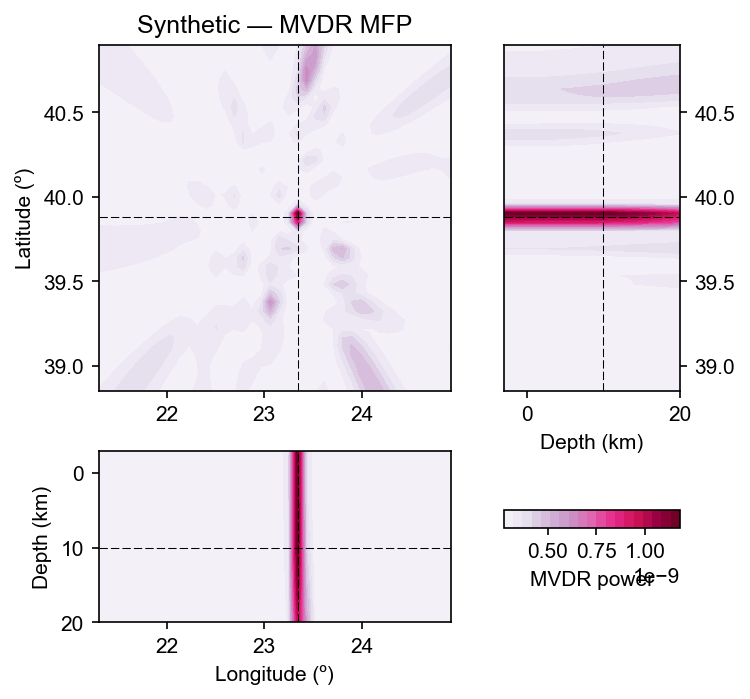

In [38]:
mfp_mvdr = MatchedFieldProcessing(travel_times)
mfp_mvdr.compute_mvdr(cov_synth, frequency)

lon_mv, lat_mv, dep_mv = mfp_mvdr.maximum_coordinates()
print(
    f"MVDR estimate: lon={lon_mv:.3f}° lat={lat_mv:.3f}° depth={dep_mv:.1f} km"
)

fig, ax = csn.plot.grid3d(
    mfp_mvdr,
    profile_coordinates=source,
    # receiver_coordinates=receiver_coords,
    cmap="PuRd",
    label="MVDR power",
)
ax["xy"].set_title("Synthetic — MVDR MFP")

## Application to the real earthquake recording

We now estimate the spectral covariance matrix from the real seismograms.
We use a 200 s window (long enough to encompass all regional arrivals) and
no spectral whitening so that the earthquake signal dominates. The covariance
at the first (and only) time window and at 3 Hz is then passed to the Bartlett
MFP, and the recovered maximum is compared with the catalogue location.


In [39]:
# Bandpass to the earthquake-signal band
stream.filter("bandpass", freqmin=0.1, freqmax=5.0)

# One long window — captures all regional arrivals, no whitening
times, frequencies, covariances = csn.calculate_covariance_matrix(
    stream, window_duration=200, average=5, whiten="none"
)

# Covariance at the target frequency (first time window)
f_target = 0.1
i_f = np.argmin(np.abs(frequencies - f_target))
cov_real = covariances[0, i_f]
print(f"Using frequency {frequencies[i_f]:.3f} Hz")

Using frequency 0.100 Hz


MFP estimate : lon=23.337° lat=39.324° depth=20.0 km
Catalogue    : lon=23.346° lat=39.881° depth=10.0 km


Text(0.5, 1.0, 'Real data — Bartlett MFP at 0.10 Hz')

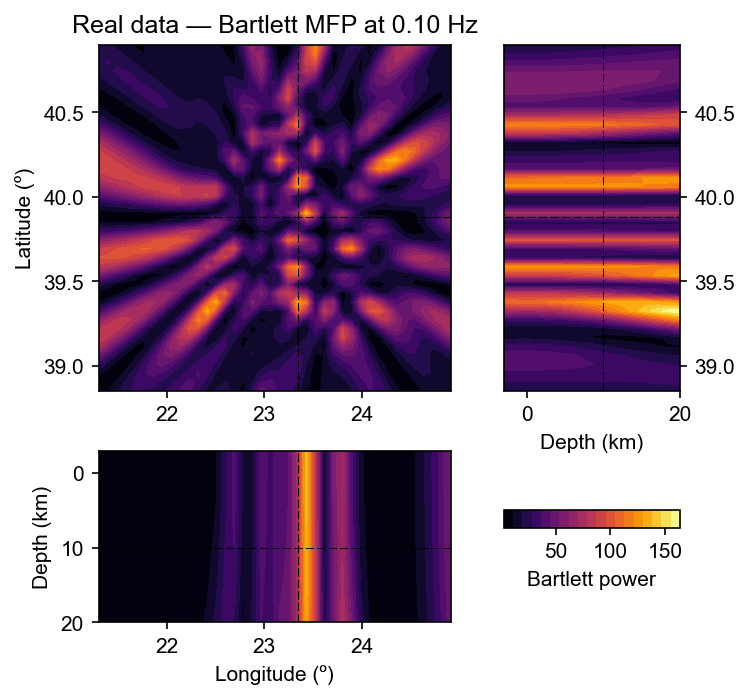

In [40]:
mfp_real = MatchedFieldProcessing(travel_times)
mfp_real.compute_bartlett(cov_real, frequencies[i_f])

lon_r, lat_r, dep_r = mfp_real.maximum_coordinates()
print(f"MFP estimate : lon={lon_r:.3f}° lat={lat_r:.3f}° depth={dep_r:.1f} km")
print(
    f"Catalogue    : lon={source[0]:.3f}° lat={source[1]:.3f}° depth={source[2]:.1f} km"
)

fig, ax = csn.plot.grid3d(
    mfp_real,
    profile_coordinates=source_location,
    receiver_coordinates=receiver_coords,
    cmap="inferno",
    label="Bartlett power",
)
ax["xy"].set_title(f"Real data — Bartlett MFP at {frequencies[i_f]:.2f} Hz")